<a href="https://colab.research.google.com/github/Uday06112006/Logistic_Regression/blob/main/Logistic_Regression_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class LogisticRegression:
    def __init__(self, lr=0.001, n_iters=1000):
        self.lr=lr
        self.n_iters=_iters
        self.weights=None
        self.bias=None
        self.loss_history=[] # To store the cost at each step

    def _sigmoid(self, x):
        return 1/(1+np.exp(-x))

    def _compute_loss(self, y, y_predicted):
        # Binary Cross-Entropy (Log Loss) formula
        epsilon=1e-15 # To avoid log(0)
        y_predicted=np.clip(y_predicted, epsilon, 1-epsilon)
        return -np.mean(y*np.log(y_predicted)+(1-y)*np.log(1-y_predicted))

    def fit(self, X, y):
        n_samples, n_features=X.shape
        self.weights=np.zeros(n_features)
        self.bias=0

        for i in range(self.n_iters):
            linear_model=np.dot(X, self.weights)+self.bias
            y_predicted=self._sigmoid(linear_model)
            # Record the loss for plotting later
            current_loss=self._compute_loss(y, y_predicted)
            self.loss_history.append(current_loss)
            # Standard Gradient Descent updates
            dw=(1/n_samples)*np.dot(X.T, (y_predicted-y))
            db=(1/n_samples)*np.sum(y_predicted-y)
            self.weights-=self.lr*dw
            self.bias-=self.lr*db

    def predict(self, X):
        linear_model=np.dot(X, self.weights)+self.bias
        y_predicted=self._sigmoid(linear_model)
        y_predicted_cls=[1 if i>0.5 else 0 for i in y_predicted]
        return np.array(y_predicted_cls)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn import datasets
# 1. Create a binary classification dataset
X, y=datasets.make_classification(n_samples=1000, n_features=10, random_state=123)
# 2. Split into Training and Testing sets
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=123)
print(f"Data ready: {X_train.shape[0]} training samples.")

Data ready: 800 training samples.


In [ ]:
# Initializeing the model
# learning rate (lr) and iterations (n_iters)
model=LogisticRegression(lr=0.1, n_iters=1000)
# Train the model
model.fit(X_train, y_train)
# For making predictions on the test set
predictions=model.predict(X_test)
# Calculating Accuracy
def accuracy(y_true, y_pred):
    accuracy=np.sum(y_true==y_pred)/len(y_true)
    return accuracy
acc=accuracy(y_test, predictions)
print(f"Model Accuracy: {acc * 100:.2f}%")

Model Accuracy: 95.50%


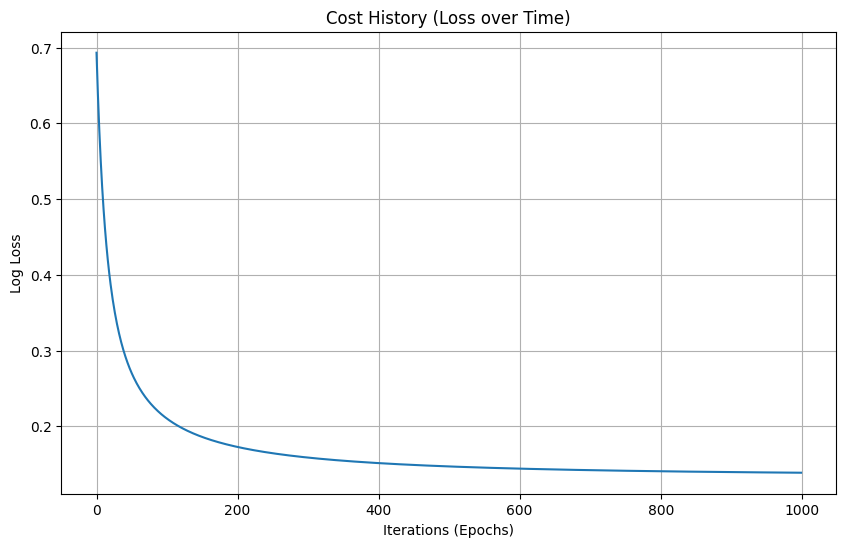

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(model.loss_history)
plt.title('Cost History (Loss over Time)')
plt.xlabel('Iterations (Epochs)')
plt.ylabel('Log Loss')
plt.grid(True)
plt.show()